In [10]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

import shap
from lime.lime_tabular import LimeTabularExplainer

In [11]:
df = pd.read_csv("dataset.csv")
df.head()

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6


In [12]:
print("the shape of the data:", df.shape)

the shape of the data: (319, 39)


In [13]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

In [14]:
df.describe() 

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
count,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.00000,319.000000,...,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000
mean,0.495298,48.068966,0.492163,0.335423,0.037618,0.028213,0.025078,0.134796,167.15674,80.564890,...,49.475549,144.502163,21.684953,26.855799,73.112539,0.800611,100.818903,1.853856,14.418182,21.401411
std,0.500763,12.114558,0.500724,0.517340,0.190568,0.165841,0.156609,0.342042,10.05303,15.709069,...,17.718701,97.904493,16.697605,27.884413,24.181069,0.176433,16.971396,4.989591,1.775815,9.981659
min,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,145.00000,42.900000,...,25.000000,1.390000,8.000000,3.000000,7.000000,0.460000,10.600000,0.000000,8.500000,3.500000
25%,0.000000,38.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,159.50000,69.600000,...,40.000000,83.000000,15.000000,14.250000,58.000000,0.650000,94.170000,0.000000,13.300000,13.250000
50%,0.000000,49.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,168.00000,78.800000,...,46.500000,119.000000,18.000000,19.000000,71.000000,0.790000,104.000000,0.215000,14.400000,22.000000
75%,1.000000,56.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,175.00000,91.250000,...,56.000000,172.000000,23.000000,30.000000,86.000000,0.920000,110.745000,1.615000,15.700000,28.060000
max,1.000000,96.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,191.00000,143.500000,...,273.000000,838.000000,195.000000,372.000000,197.000000,1.460000,132.000000,43.400000,18.800000,53.100000


In [15]:
print("the number of duplicated rows:", df.duplicated().sum())

the number of duplicated rows: 0


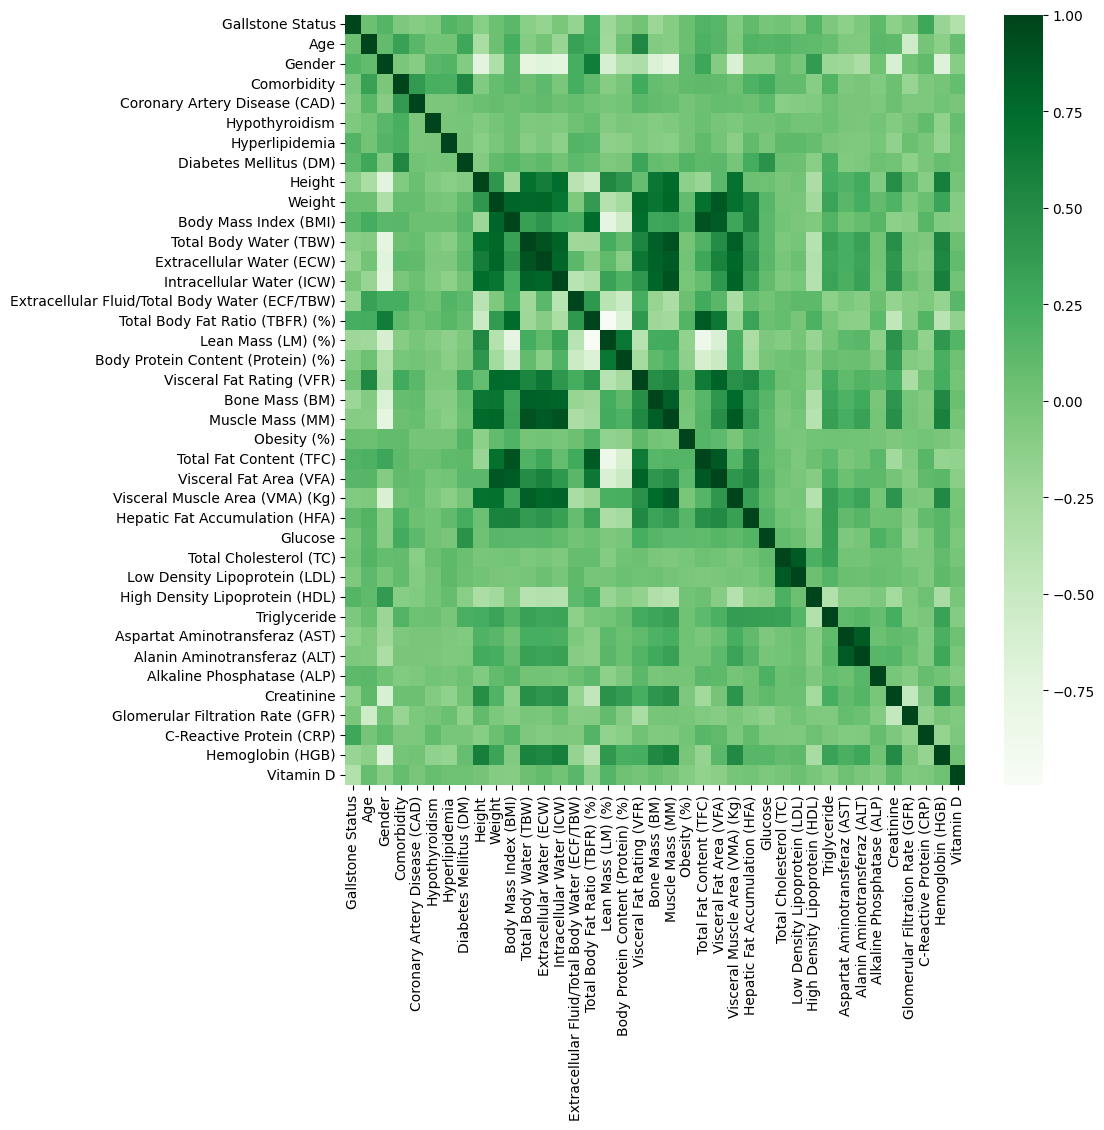

In [16]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), cmap='Greens') 
plt.show() 

In [17]:
#input data
x = df.drop(["Gallstone Status"], axis = 1)

#output data
y = df["Gallstone Status"]

In [18]:
#Split the data to training and testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [19]:
#Feature Scaling 
scaler = StandardScaler() 
x_train_scaled = scaler.fit_transform(x_train) 
x_test_scaled = scaler.transform(x_test) 

In [20]:
'''
SVM
Random forest 
Xg boost
Gradient boosting
'''

'SVM\nDecision tree\nRandom forest \nXg boost\nGradient boosting'

In [21]:
rf_params = {'n_estimators': [50, 100, 150],'max_features': ['sqrt', 'log2'], 'max_depth' : [5, 10, 15]}
rf_model = RandomForestClassifier(random_state=42)

rf_grid = GridSearchCV(rf_model, rf_params, cv=5, scoring='accuracy', return_train_score=True)
rf_grid.fit(x_train_scaled, y_train) 

Best_parameter = rf_grid.best_params_ 
Validation_accuracy = rf_grid.best_score_ 
best_index = rf_grid.best_index_
Training_Accuracy = rf_grid.cv_results_['mean_train_score'][best_index]


print("Best parameter:", Best_parameter) 
print("Training Accuracy:", Training_Accuracy)
print("Validation accuracy:", Validation_accuracy) 

Best parameter: {'max_depth': 5, 'max_features': 'log2', 'n_estimators': 150}
Training Accuracy 0.9784313725490197
Validation accuracy: 0.7843137254901962


In [22]:
gb_params = {'n_estimators': [50, 100],'learning_rate': [0.05, 0.1],'max_depth': [5, 10]}
gb_model = GradientBoostingClassifier(random_state=42)

gb_grid = GridSearchCV(gb_model, gb_params, cv=5, scoring='accuracy', return_train_score=True)
gb_grid.fit(x_train_scaled, y_train)

Best_parameter = gb_grid.best_params_ 
Validation_accuracy = gb_grid.best_score_ 
best_index = gb_grid.best_index_
Training_Accuracy = gb_grid.cv_results_['mean_train_score'][best_index]

print("Best parameter:", Best_parameter) 
print("Training Accuracy:", Training_Accuracy)
print("Validation accuracy:", Validation_accuracy) 

Best parameter: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Training Accuracy 1.0
Validation accuracy: 0.7411764705882353


In [39]:
xgb_params = {'n_estimators': [50, 100],'learning_rate': [0.05, 0.1],'max_depth': [3, 5]}
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)

xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=5, scoring='accuracy', return_train_score=True)
xgb_grid.fit(x_train_scaled, y_train)

Best_parameter = xgb_grid.best_params_ 
Validation_accuracy = xgb_grid.best_score_ 
best_index = xgb_grid.best_index_
Training_Accuracy = xgb_grid.cv_results_['mean_train_score'][best_index]

print("Best parameter:", Best_parameter) 
print("Training Accuracy:", Training_Accuracy)
print("Validation accuracy:", Validation_accuracy) 

Best parameter: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Training Accuracy 0.9833333333333334
Validation accuracy: 0.7686274509803921


In [24]:
svm_params = {'C': [0.1, 1, 10],'kernel': ['linear', 'rbf']}
svm_model = SVC()

svm_grid = GridSearchCV(svm_model, svm_params, cv=5, scoring='accuracy', return_train_score=True)
svm_grid.fit(x_train_scaled, y_train)

Best_parameter = svm_grid.best_params_ 
Validation_accuracy = svm_grid.best_score_ 
best_index = svm_grid.best_index_
Training_Accuracy = svm_grid.cv_results_['mean_train_score'][best_index]

print("Best parameter:", Best_parameter) 
print("Training Accuracy:", Training_Accuracy) 
print("Validation accuracy:", Validation_accuracy) 

Best parameter: {'C': 1, 'kernel': 'linear'}
Training Accuracy 0.8637254901960784
Validation accuracy: 0.7882352941176471


 .

**Evaluate the performance of the best models**

In [25]:
#Random Forest Evaluation

best_rf_model = rf_grid.best_estimator_
y_pred_rf = best_rf_model.predict(x_test_scaled)


ac = accuracy_score(y_test, y_pred_rf) 
pc = precision_score(y_test, y_pred_rf)
rc = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
class_report = classification_report(y_test, y_pred_rf) 

print("the accuracy score =", ac)
print("the precision score =", pc)
print("the recall score =", rc)
print("the f1 score =", f1)
print("")
print("the classification report =")
print(class_report)


the accuracy score = 0.8125
the precision score = 0.8064516129032258
the recall score = 0.8064516129032258
the f1 score = 0.8064516129032258

the classification report =
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        33
           1       0.81      0.81      0.81        31

    accuracy                           0.81        64
   macro avg       0.81      0.81      0.81        64
weighted avg       0.81      0.81      0.81        64



In [26]:
#Gradient Boosting Evaluation

best_gb_model = gb_grid.best_estimator_
y_pred_gb = best_gb_model.predict(x_test_scaled)


ac = accuracy_score(y_test, y_pred_gb) 
pc = precision_score(y_test, y_pred_gb)
rc = recall_score(y_test, y_pred_gb)
f1 = f1_score(y_test, y_pred_gb)
class_report = classification_report(y_test, y_pred_gb) 

print("the accuracy score =", ac)
print("the precision score =", pc)
print("the recall score =", rc)
print("the f1 score =", f1)
print("")
print("the classification report =")
print(class_report)


the accuracy score = 0.84375
the precision score = 0.8888888888888888
the recall score = 0.7741935483870968
the f1 score = 0.8275862068965517

the classification report =
              precision    recall  f1-score   support

           0       0.81      0.91      0.86        33
           1       0.89      0.77      0.83        31

    accuracy                           0.84        64
   macro avg       0.85      0.84      0.84        64
weighted avg       0.85      0.84      0.84        64



In [40]:
#XG Boosting Evaluation

best_xgb_model = xgb_grid.best_estimator_
y_pred_xgb = best_xgb_model.predict(x_test_scaled)


ac = accuracy_score(y_test, y_pred_xgb) 
pc = precision_score(y_test, y_pred_xgb)
rc = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)
class_report = classification_report(y_test, y_pred_xgb) 

print("the accuracy score =", ac)
print("the precision score =", pc)
print("the recall score =", rc)
print("the f1 score =", f1)
print("")
print("the classification report =")
print(class_report)


the accuracy score = 0.8125
the precision score = 0.8275862068965517
the recall score = 0.7741935483870968
the f1 score = 0.8

the classification report =
              precision    recall  f1-score   support

           0       0.80      0.85      0.82        33
           1       0.83      0.77      0.80        31

    accuracy                           0.81        64
   macro avg       0.81      0.81      0.81        64
weighted avg       0.81      0.81      0.81        64



In [28]:
#SVM Evaluation

best_svm_model = svm_grid.best_estimator_
y_pred_svm = best_svm_model.predict(x_test_scaled)


ac = accuracy_score(y_test, y_pred_svm) 
pc = precision_score(y_test, y_pred_svm)
rc = recall_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm)
class_report = classification_report(y_test, y_pred_svm) 

print("the accuracy score =", ac)
print("the precision score =", pc)
print("the recall score =", rc)
print("the f1 score =", f1)
print("")
print("the classification report =")
print(class_report) 


the accuracy score = 0.796875
the precision score = 0.8461538461538461
the recall score = 0.7096774193548387
the f1 score = 0.7719298245614035

the classification report =
              precision    recall  f1-score   support

           0       0.76      0.88      0.82        33
           1       0.85      0.71      0.77        31

    accuracy                           0.80        64
   macro avg       0.80      0.79      0.79        64
weighted avg       0.80      0.80      0.80        64



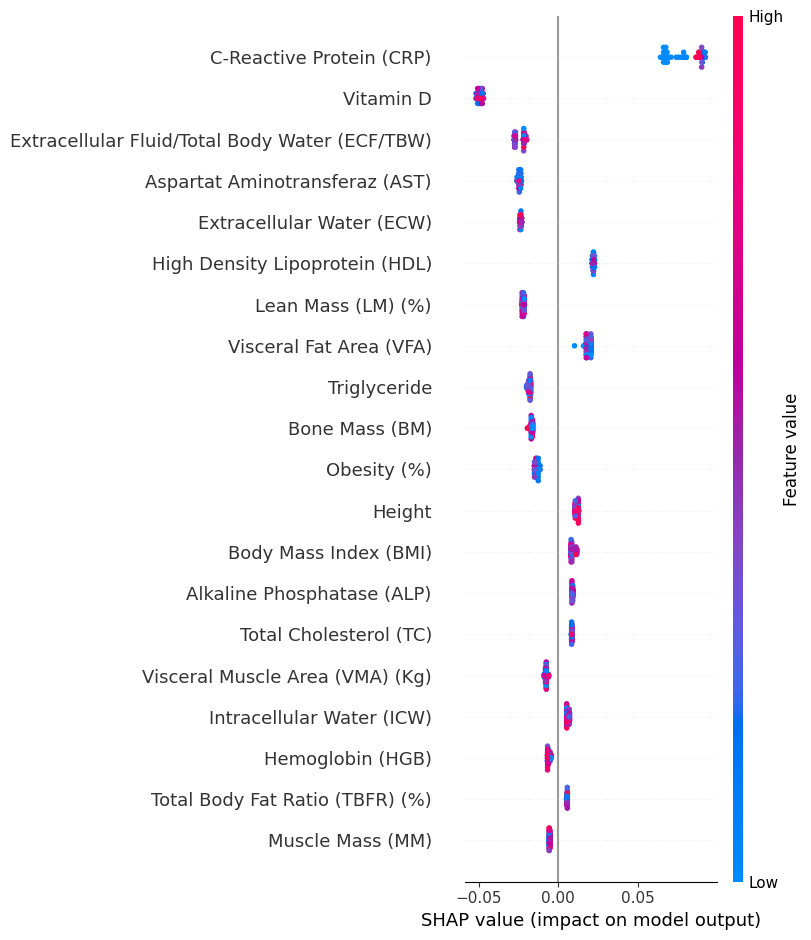

In [29]:
#Use SHAP to visualize global feature importance for the Random Forest model.

explainer = shap.TreeExplainer(best_rf_model)
shap_values = explainer(x_test)
shap.summary_plot(shap_values[:,:,1], x_test, show=True)

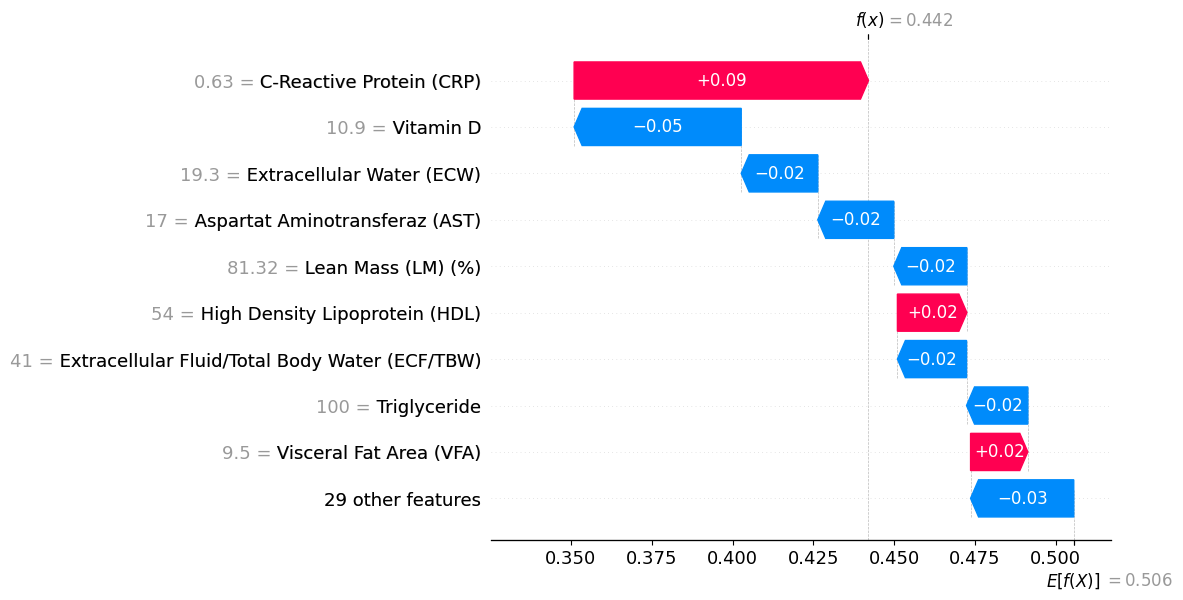

In [30]:
# Explain one prediction using SHAP and visualize feature contributions with a waterfall plot.
shap_values = explainer(x_test[0:1])
shap.plots.waterfall(shap_values[0,:,1]) 


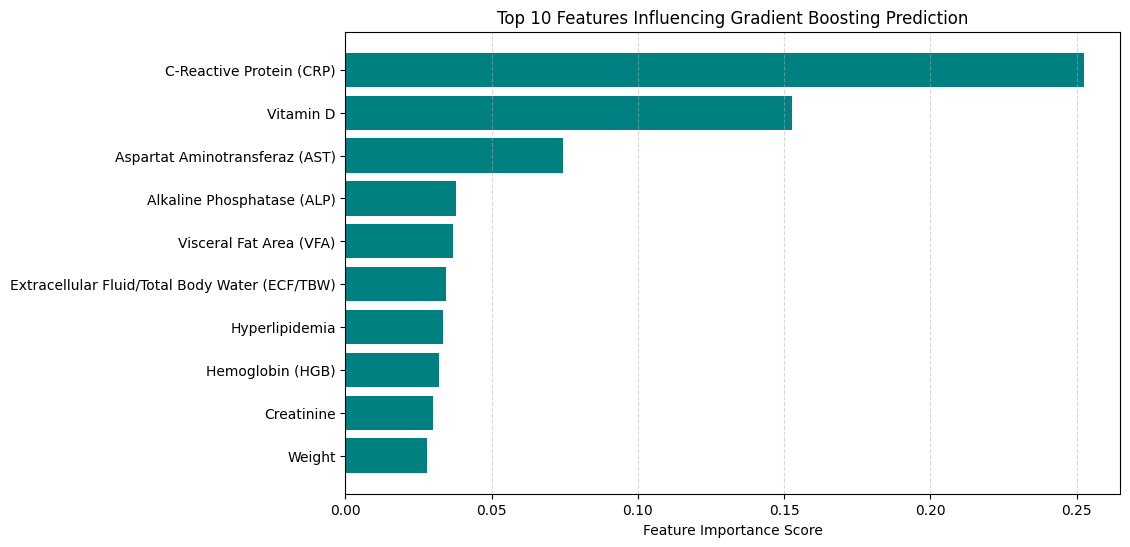

Top 10 Features based on Gradient Boosting Importance:
                                           Feature  Importance
35                        C-Reactive Protein (CRP)    0.252408
37                                       Vitamin D    0.152658
30                  Aspartat Aminotransferaz (AST)    0.074454
32                      Alkaline Phosphatase (ALP)    0.037845
22                         Visceral Fat Area (VFA)    0.036927
13  Extracellular Fluid/Total Body Water (ECF/TBW)    0.034260
5                                   Hyperlipidemia    0.033381
36                                Hemoglobin (HGB)    0.031952
33                                      Creatinine    0.030019
8                                           Weight    0.027988


In [36]:
#Visualizing Top 10 Important Features for Gradient Boosting Model 

importances = best_gb_model.feature_importances_
feature_importance_gb = pd.DataFrame({'Feature': x.columns,'Importance': importances})
top_features_gb = feature_importance_gb.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features_gb['Feature'], top_features_gb['Importance'], color='teal')
plt.xlabel('Feature Importance Score')
plt.title('Top 10 Features Influencing Gradient Boosting Prediction')
plt.gca().invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

print("Top 10 Features based on Gradient Boosting Importance:")
print(top_features_gb)